# Group 2604 Members

| Name | Family Name | Matriculation Number |
|------|-------------|----------------------|
| Luca | Di Turi | 2196579 |
| Alessandro | Turino | 2205737 |
| Mattia | Ziglioli | 2198835 |
| Andrea | Marchetti | 2197526 |

# Exercise 3: XGBoost

**3.1**: Exploring model complexity (parameters and regularization)  
**3.2**: Dimensionality reduction through feature selection

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import StratifiedKFold, cross_val_score

mpl.rcParams['image.cmap'] = 'winter'
plt.rcParams['font.size'] = 13
np.random.seed(12345)

## Load and spit data

In [3]:
dname = "./DATA/"
x = np.loadtxt(dname + 'x_XGB_26.dat', delimiter=" ", dtype=float)
y = np.loadtxt(dname + 'y_XGB_26.dat').astype(int)

N, L = len(x), len(x[0])          # N=5000 samples, L=4 features
N_train = int(0.75 * N)            # 3750 train, 1250 validation

x_train, y_train = x[:N_train], y[:N_train]
x_test,  y_test  = x[N_train:],  y[N_train:]

print(f"N={N}, N_train={N_train}, N_test={N-N_train}, L={L}")

N=5000, N_train=3750, N_test=1250, L=4


---
# 3.1 — Model Complexity and Regularization

Exploring the effect of:
- `n_estimators`: number of trees used for boosting
- `max_depth`: maximum tree depth
- `reg_lambda` (λ): L2 regularization (avoids big weights in the leafs)
- `gamma` (γ): minimum gain for a split

We use **cross-validation** on 5 folds to compare the different models in a more robust way.

In [4]:
# ---------------------------------------------------------------
# Utilities: trains, evaluates and prints accuracy of the model
# Outputs: acc_train, acc_test, acc_cv_mean, acc_cv_std
# ---------------------------------------------------------------
def evaluate(model, label="", cv_folds=5):
    model.fit(x_train, y_train)
    acc_train = model.score(x_train, y_train)
    acc_test  = model.score(x_test,  y_test)

    # Cross-validation on the whole dataset (x, y)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, x, y, cv=cv, scoring='accuracy')
    
    print(f"{label:45s} | train={acc_train:.3f} | val={acc_test:.3f} "
          f"| CV={cv_scores.mean():.3f}±{cv_scores.std():.3f}")
    return acc_train, acc_test, cv_scores.mean(), cv_scores.std()

### 1a — Reference model: using default parameters

We start from the "base" model to have a reference score

In [5]:
# Reference model: default XGBoost
# n_estimators=100, max_depth=6, reg_lambda=1, gamma=0
model_base = XGBClassifier(
    objective='binary:logistic',
    seed=1, verbosity=0
)

print(f"{'Config':45s} | {'train':>9} | {'val':>7} | {'CV mean±std':>15}")
print("-" * 85)
evaluate(model_base, "Baseline (default)")

Config                                        |     train |     val |     CV mean±std
-------------------------------------------------------------------------------------
Baseline (default)                            | train=1.000 | val=0.934 | CV=0.936±0.004


(0.9997333333333334,
 0.9336,
 np.float64(0.9358000000000001),
 np.float64(0.00421426150114105))

### 1b — Varying `n_estimators` (number of trees)

Augmenting the number of trees used, the boosting becomes more expressive, but tends to overfit and it becomes more computationally expensive. We are searching the saturation point for this variable.

In [6]:
n_est_values = [5, 10, 20, 50, 100, 200, 500]

results_nest = []
print(f"{'Config':45s} | {'train':>9} | {'val':>7} | {'CV mean±std':>15}")
print("-" * 85)

for n in n_est_values:
    m = XGBClassifier(
        n_estimators=n,
        objective='binary:logistic',
        seed=1, verbosity=0
    )
    res = evaluate(m, f"n_estimators={n}")
    results_nest.append(res)

Config                                        |     train |     val |     CV mean±std
-------------------------------------------------------------------------------------
n_estimators=5                                | train=0.878 | val=0.829 | CV=0.864±0.020
n_estimators=10                               | train=0.934 | val=0.877 | CV=0.888±0.009
n_estimators=20                               | train=0.965 | val=0.900 | CV=0.915±0.008
n_estimators=50                               | train=0.993 | val=0.923 | CV=0.933±0.005
n_estimators=100                              | train=1.000 | val=0.934 | CV=0.936±0.004
n_estimators=200                              | train=1.000 | val=0.935 | CV=0.936±0.004
n_estimators=500                              | train=1.000 | val=0.928 | CV=0.935±0.005


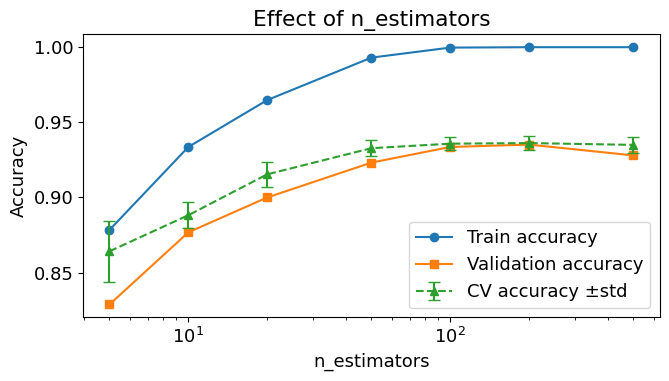

In [7]:
# --- Plot: accuracy vs n_estimators ---
train_acc = [r[0] for r in results_nest]
test_acc  = [r[1] for r in results_nest]
cv_mean   = [r[2] for r in results_nest]
cv_std    = [r[3] for r in results_nest]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(n_est_values, train_acc, 'o-', label='Train accuracy')
ax.plot(n_est_values, test_acc,  's-', label='Validation accuracy')
ax.errorbar(n_est_values, cv_mean, yerr=cv_std, fmt='^--', capsize=4, label='CV accuracy ±std')
ax.set_xlabel("n_estimators")
ax.set_ylabel("Accuracy")
ax.set_title("Effect of n_estimators")
ax.legend()
ax.set_xscale('log')
plt.tight_layout()
plt.show()

We see that the accuracy is approximately stable for values of trees used in the range $[100,200]$.

### 1c — Varying `max_depth` (maximum trees depth)

Deeper trees can express more complex interaction between features, risking overfitting. 

A little `max_depth` (1-3) corresponds to a simpler model.


In [8]:
depth_values = [1, 2, 3, 4, 6, 8, 10]

results_depth = []
print(f"{'Config':45s} | {'train':>9} | {'val':>7} | {'CV mean±std':>15}")
print("-" * 85)

for d in depth_values:
    m = XGBClassifier(
        max_depth=d,
        objective='binary:logistic',
        seed=1, verbosity=0
    )
    res = evaluate(m, f"max_depth={d}")
    results_depth.append(res)

Config                                        |     train |     val |     CV mean±std
-------------------------------------------------------------------------------------
max_depth=1                                   | train=0.666 | val=0.620 | CV=0.627±0.014
max_depth=2                                   | train=0.797 | val=0.749 | CV=0.755±0.016
max_depth=3                                   | train=0.917 | val=0.847 | CV=0.852±0.012
max_depth=4                                   | train=0.981 | val=0.905 | CV=0.914±0.006
max_depth=6                                   | train=1.000 | val=0.934 | CV=0.936±0.004
max_depth=8                                   | train=1.000 | val=0.938 | CV=0.940±0.004
max_depth=10                                  | train=1.000 | val=0.938 | CV=0.941±0.007


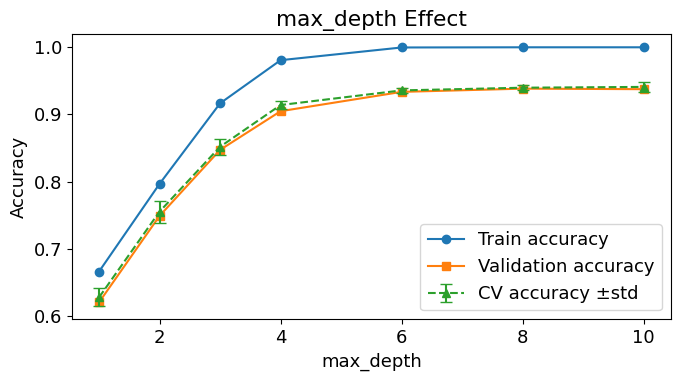

In [9]:
# --- Plot: accuracy vs max_depth ---
train_acc = [r[0] for r in results_depth]
test_acc  = [r[1] for r in results_depth]
cv_mean   = [r[2] for r in results_depth]
cv_std    = [r[3] for r in results_depth]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(depth_values, train_acc, 'o-', label='Train accuracy')
ax.plot(depth_values, test_acc,  's-', label='Validation accuracy')
ax.errorbar(depth_values, cv_mean, yerr=cv_std, fmt='^--', capsize=4, label='CV accuracy ±std')
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.set_title("max_depth Effect")
ax.legend()
plt.tight_layout()
plt.show()

We see that the accuracy is approximately stable for maximum depths values `max_depths` > 4.

### 1d — Regularization: `reg_lambda` (λ) and `gamma` (γ)

**`reg_lambda`** (L2): adds a λ·||w||² term to the cost function.
High values lead to more conservative leafs (small weights).
We examine the default value, 0 vs high regularization values 10-100.

**`gamma`**: minimum loss threshold to make a split. Avoids less useful nodes. 
Higher values lead to simpler trees.

In [10]:
lambda_values = [0, 0.01, 0.1, 1, 10, 100]
gamma_values  = [0, 0.1,  1,   5, 10]

print("=== Varying reg_lambda (γ=0 fixed) ===")
print(f"{'Config':45s} | {'train':>9} | {'val':>7} | {'CV mean±std':>15}")
print("-" * 85)
results_lam = []
for lam in lambda_values:
    m = XGBClassifier(
        reg_lambda=lam, gamma=0,
        objective='binary:logistic',
        seed=1, verbosity=0
    )
    res = evaluate(m, f"reg_lambda={lam}, gamma=0")
    results_lam.append(res)

print()
print("=== Varying gamma (λ=1 fixed) ===")
print(f"{'Config':45s} | {'train':>9} | {'val':>7} | {'CV mean±std':>15}")
print("-" * 85)
results_gam = []
for g in gamma_values:
    m = XGBClassifier(
        reg_lambda=1, gamma=g,
        objective='binary:logistic',
        seed=1, verbosity=0
    )
    res = evaluate(m, f"reg_lambda=1, gamma={g}")
    results_gam.append(res)

=== Varying reg_lambda (γ=0 fixed) ===
Config                                        |     train |     val |     CV mean±std
-------------------------------------------------------------------------------------
reg_lambda=0, gamma=0                         | train=1.000 | val=0.920 | CV=0.935±0.001
reg_lambda=0.01, gamma=0                      | train=1.000 | val=0.927 | CV=0.937±0.004
reg_lambda=0.1, gamma=0                       | train=1.000 | val=0.925 | CV=0.940±0.003
reg_lambda=1, gamma=0                         | train=1.000 | val=0.934 | CV=0.936±0.004
reg_lambda=10, gamma=0                        | train=0.993 | val=0.926 | CV=0.935±0.005
reg_lambda=100, gamma=0                       | train=0.962 | val=0.887 | CV=0.902±0.009

=== Varying gamma (λ=1 fixed) ===
Config                                        |     train |     val |     CV mean±std
-------------------------------------------------------------------------------------
reg_lambda=1, gamma=0                         | 

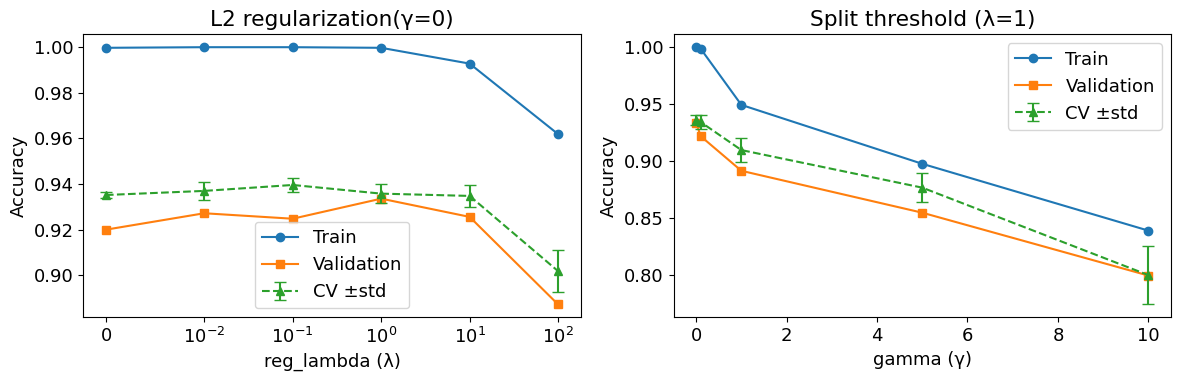

In [11]:
# --- Plot: regularization effect ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Lambda
ax = axes[0]
ax.plot(lambda_values, [r[0] for r in results_lam], 'o-', label='Train')
ax.plot(lambda_values, [r[1] for r in results_lam], 's-', label='Validation')
ax.errorbar(lambda_values, [r[2] for r in results_lam],
            yerr=[r[3] for r in results_lam], fmt='^--', capsize=4, label='CV ±std')
ax.set_xscale('symlog', linthresh=0.01)  
ax.set_xlabel("reg_lambda (λ)")
ax.set_ylabel("Accuracy")
ax.set_title("L2 regularization(γ=0)")
ax.legend()

# Gamma
ax = axes[1]
ax.plot(gamma_values, [r[0] for r in results_gam], 'o-', label='Train')
ax.plot(gamma_values, [r[1] for r in results_gam], 's-', label='Validation')
ax.errorbar(gamma_values, [r[2] for r in results_gam],
            yerr=[r[3] for r in results_gam], fmt='^--', capsize=4, label='CV ±std')
ax.set_xlabel("gamma (γ)")
ax.set_ylabel("Accuracy")
ax.set_title("Split threshold (λ=1)")
ax.legend()

plt.tight_layout()
plt.show()

We see that values of lambda in the range $[0.01,10]$ lead to similar accuracy values. Whereas high gamma values reduce a lot the validation accuracy. For this reason we examine a lower range of gamma values, using a logarithmic scale.

In [12]:
gamma_values  = [0, 0.001,0.01,0.1, 1]

print("=== Varying gamma (λ=1 fixed) ===")
print(f"{'Config':45s} | {'train':>9} | {'val':>7} | {'CV mean±std':>15}")
print("-" * 85)
results_gam = []
for g in gamma_values:
    m = XGBClassifier(
        reg_lambda=1, gamma=g,
        objective='binary:logistic',
        seed=1, verbosity=0
    )
    res = evaluate(m, f"reg_lambda=1, gamma={g}")
    results_gam.append(res)

=== Varying gamma (λ=1 fixed) ===
Config                                        |     train |     val |     CV mean±std
-------------------------------------------------------------------------------------
reg_lambda=1, gamma=0                         | train=1.000 | val=0.934 | CV=0.936±0.004
reg_lambda=1, gamma=0.001                     | train=1.000 | val=0.934 | CV=0.937±0.004
reg_lambda=1, gamma=0.01                      | train=0.999 | val=0.926 | CV=0.938±0.004
reg_lambda=1, gamma=0.1                       | train=0.998 | val=0.922 | CV=0.934±0.006
reg_lambda=1, gamma=1                         | train=0.949 | val=0.891 | CV=0.909±0.010


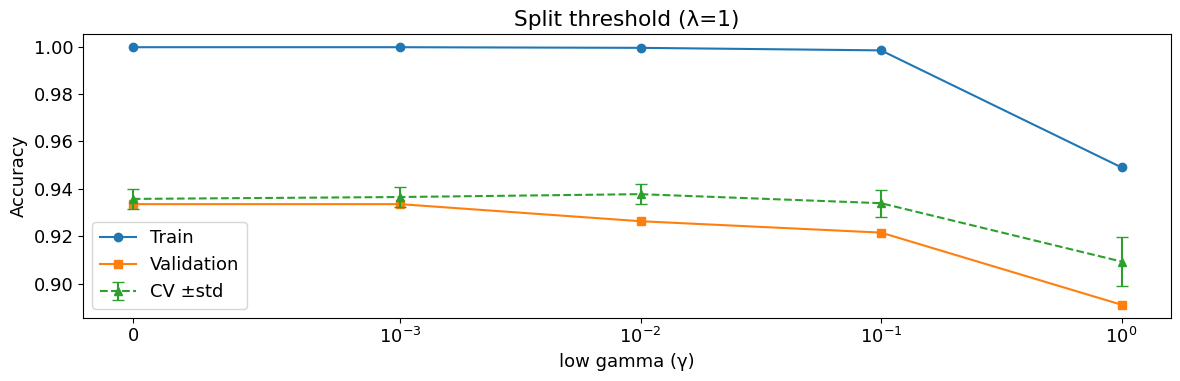

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))

# Gamma
ax.plot(gamma_values, [r[0] for r in results_gam], 'o-', label='Train')
ax.plot(gamma_values, [r[1] for r in results_gam], 's-', label='Validation')
ax.errorbar(gamma_values, [r[2] for r in results_gam],
            yerr=[r[3] for r in results_gam], fmt='^--', capsize=4, label='CV ±std')
ax.set_xscale('symlog', linthresh=0.001)  
ax.set_xlabel("low gamma (γ)")
ax.set_ylabel("Accuracy")
ax.set_title("Split threshold (λ=1)")
ax.legend()

plt.tight_layout()
plt.show()

We see that values of lambda $\gamma<0.1$ lead to similar accuracy results.

### 1e — Best simple model

From the graphs above, we can deduce that optimal values for the parameter can be chosen in the range:
- `n_estimators`: $[100,200]$
- `max_depths` : $(4,\infty]$
- `reg_lambda`: $[0.01,10]$
- `gamma`: $[0,0.1)$


In [13]:
n_est_best = 100
depth_best = 5
lam_best   = 1
gamma_best = 0.001

model_minimal = XGBClassifier(
    n_estimators=n_est_best,
    max_depth=depth_best,
    reg_lambda=lam_best,
    gamma=gamma_best,
    objective='binary:logistic',
    importance_type='gain',
    seed=1, verbosity=0
)

print(f"{'Config':45s} | {'train':>9} | {'val':>7} | {'CV mean±std':>15}")
print("-" * 85)
evaluate(model_base,    "Baseline (default, n=100 d=6)")
evaluate(model_minimal, f"Optimal (n={n_est_best}, d={depth_best}, λ={lam_best}, γ={gamma_best})")

Config                                        |     train |     val |     CV mean±std
-------------------------------------------------------------------------------------
Baseline (default, n=100 d=6)                 | train=1.000 | val=0.934 | CV=0.936±0.004
Optimal (n=100, d=5, λ=1, γ=0.001)            | train=0.998 | val=0.920 | CV=0.932±0.006


(0.9981333333333333, 0.92, 0.9324, 0.006468384651518459)

---
# 3.2 — Dimensionality reduction

Idea: We want to remove less important features, in order to:
- reduce training noise
- improve o maintain the baseline accuracy
- simplify the model

Steps:
    We proceed by visualizing the feature importances of the trained model, we then
    train it in subset of features (2 or 3), we compare the obtained accuracies.

### 2a — Optimal model feature importances

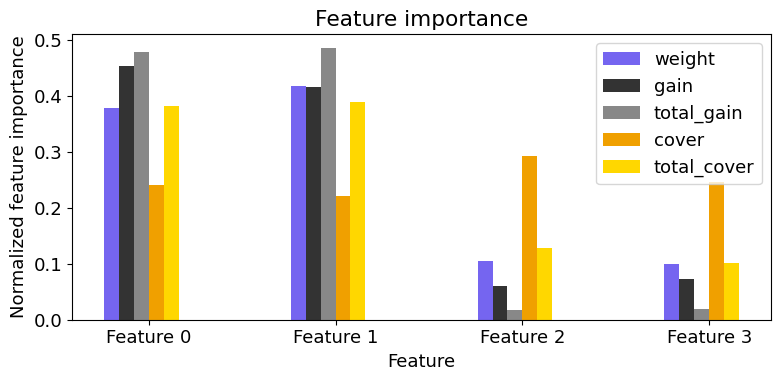

Importance (gain):
  Feature 0: 5.43
  Feature 1: 5.00
  Feature 2: 0.72
  Feature 3: 0.86


In [14]:
# Train on the whole training set
model_minimal.fit(x_train, y_train)

list_type = ["weight", "gain", "total_gain", "cover", "total_cover"]
list_col  = ["#7565F0", "#333333", "#888888", "#F0A000", "#FFD700"]

fig, ax = plt.subplots(figsize=(8, 4))
for i, (t, col) in enumerate(zip(list_type, list_col)):
    scores = model_minimal.get_booster().get_score(importance_type=t)

    values = np.array([scores.get(f'f{j}', 0) for j in range(L)])
    values_norm = values / values.sum() if values.sum() > 0 else values
    offset = (i - len(list_type)/2) * 0.08
    ax.bar(np.arange(L) + offset, values_norm, width=0.08, color=col, label=t)

ax.set_xlabel("Feature")
ax.set_ylabel("Normalized feature importance")
ax.set_title("Feature importance")
ax.set_xticks(np.arange(L))
ax.set_xticklabels([f"Feature {i}" for i in range(L)])
ax.legend()
plt.tight_layout()
plt.show()

# Printing 'gain' of the different features
gains = model_minimal.get_booster().get_score(importance_type='gain')
print("Importance (gain):")
for j in range(L):
    print(f"  Feature {j}: {gains.get(f'f{j}', 0):.2f}")

### 2b — Reduced features training

We try all the relevant combinations:
- L'= 4 (all features) — baseline
- L'= 3 (excluding feature 2)
- L'= 3 (excluding feature 3)
- L'= 2 (excluding features 2 and 3)

In [15]:
# ---------------------------------------------------------------
# Function: trains and evaluates on a subset of features
# features: list od indexes to use, ex. [0,1,2]
# ---------------------------------------------------------------
def evaluate_features(features, label="", cv_folds=5):
    X_tr = x_train[:, features]
    X_te = x_test[:,  features]
    X_all = x[:, features]          

    m = XGBClassifier(
        n_estimators=n_est_best,
        max_depth=depth_best,
        reg_lambda=lam_best,
        gamma=gamma_best,
        objective='binary:logistic',
        seed=1, verbosity=0
    )
    m.fit(X_tr, y_train)
    acc_train = m.score(X_tr, y_train)
    acc_test  = m.score(X_te, y_test)

    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    cv_scores = cross_val_score(m, X_all, y, cv=cv, scoring='accuracy')

    print(f"{label:45s} | train={acc_train:.3f} | val={acc_test:.3f} "
          f"| CV={cv_scores.mean():.3f}±{cv_scores.std():.3f}")
    return acc_train, acc_test, cv_scores.mean(), cv_scores.std(), m


# Defining the combinations to use

feature_sets = {
    "All (0,1,2,3)": [0, 1, 2, 3],
    "No 3": [0, 1, 3],
    "No 4": [0, 1, 2],
    "Best 2": [0, 1],
    "Worst 2": [2, 3],
}

print(f"{'Config':45s} | {'train':>9} | {'val':>7} | {'CV mean±std':>15}")
print("-" * 85)

results_feat = {}
for name, feats in feature_sets.items():
    res = evaluate_features(feats, f"Features {feats}")
    results_feat[name] = res

Config                                        |     train |     val |     CV mean±std
-------------------------------------------------------------------------------------
Features [0, 1, 2, 3]                         | train=0.998 | val=0.920 | CV=0.932±0.006
Features [0, 1, 3]                            | train=0.997 | val=0.935 | CV=0.936±0.005
Features [0, 1, 2]                            | train=0.996 | val=0.932 | CV=0.936±0.009
Features [0, 1]                               | train=0.994 | val=0.932 | CV=0.944±0.006
Features [2, 3]                               | train=0.774 | val=0.514 | CV=0.500±0.008


### 2c — Comparative Plot

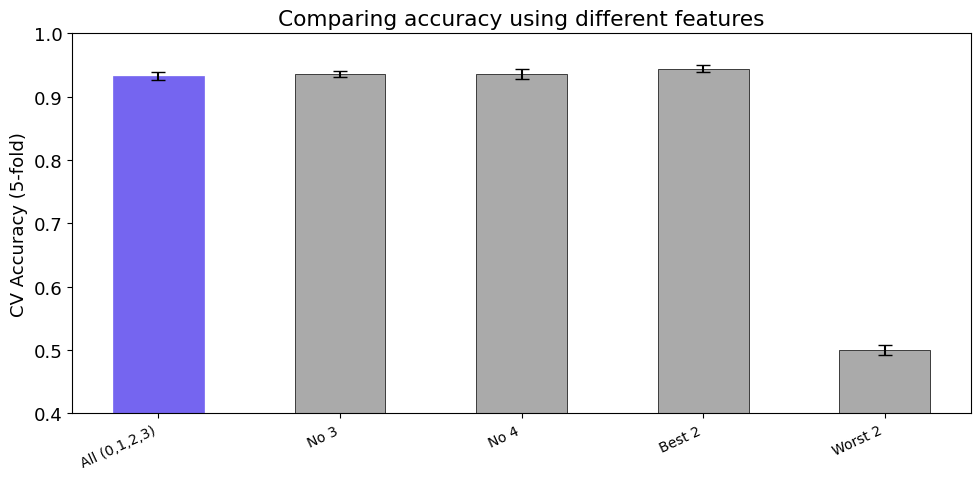


 Short review:
Features                                      |     CV accuracy
-----------------------------------------------------------------
All (0,1,2,3)                                 | 0.932 ± 0.006
No 3                                          | 0.936 ± 0.005
No 4                                          | 0.936 ± 0.009
Best 2                                        | 0.944 ± 0.006
Worst 2                                       | 0.500 ± 0.008


In [16]:
labels    = list(results_feat.keys())
cv_means  = [results_feat[k][2] for k in labels]
cv_stds   = [results_feat[k][3] for k in labels]
val_accs  = [results_feat[k][1] for k in labels]

x_pos = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(x_pos, cv_means, yerr=cv_stds, capsize=5,
              color=["#7565F0"] + ["#AAAAAA"] * (len(labels)-1),
              edgecolor='k', linewidth=0.5, width=0.5)

bars[0].set_color("#7565F0")

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=25, ha='right', fontsize=10)
ax.set_ylabel("CV Accuracy (5-fold)")
ax.set_title("Comparing accuracy using different features")
ax.set_ylim(0.4, 1.0)
plt.tight_layout()
plt.show()

print("\n Short review:")
print(f"{'Features':45s} | {'CV accuracy':>15}")
print("-" * 65)
for k in labels:
    m, s = results_feat[k][2], results_feat[k][3]
    print(f"{k:45s} | {m:.3f} ± {s:.3f}")

Obviously, the exclusion of the last 2 features from training data leads to an increase in the validation accuracy of the model, since they only simulate noise in this exercise.

### 2d — Feature importance of the reduced model (comparison)

We visualize the feature importance of the model trained on the reduced set, and we verify the distribution of the remaining features.

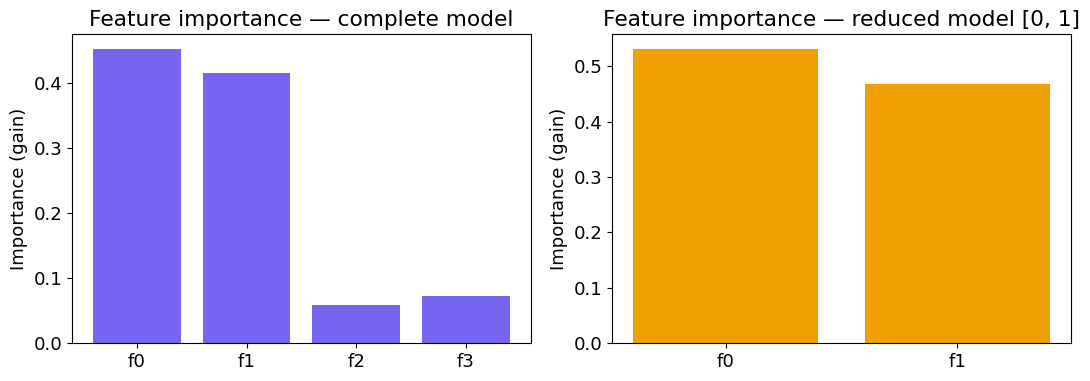

In [17]:
best_reduced_key = "Best 2"
model_reduced = results_feat[best_reduced_key][4]
feats_reduced = feature_sets[best_reduced_key]
L_red = len(feats_reduced)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

fi_full = model_minimal.feature_importances_
axes[0].bar(np.arange(L), fi_full, color="#7565F0")
axes[0].set_xticks(np.arange(L))
axes[0].set_xticklabels([f"f{i}" for i in range(L)])
axes[0].set_title("Feature importance — complete model")
axes[0].set_ylabel("Importance (gain)")

fi_red = model_reduced.feature_importances_
axes[1].bar(np.arange(L_red), fi_red, color="#F0A000")
axes[1].set_xticks(np.arange(L_red))
axes[1].set_xticklabels([f"f{i}" for i in feats_reduced])
axes[1].set_title(f"Feature importance — reduced model {feats_reduced}")
axes[1].set_ylabel("Importance (gain)")

plt.tight_layout()
plt.show()

---
## Review 3.1,3.2


In [18]:
print("=" * 60)
print("1 — Best efficient model")
print("=" * 60)
print(f"  n_estimators : {n_est_best}")
print(f"  max_depth    : {depth_best}")
print(f"  reg_lambda   : {lam_best}")
print(f"  gamma        : {gamma_best}")
print()

print("=" * 60)
print("2 — Feature selection")
print("=" * 60)
for k in labels:
    m, s = results_feat[k][2], results_feat[k][3]
    print(f"  {k:<40s} CV={m:.3f}±{s:.3f}")

1 — Best efficient model
  n_estimators : 100
  max_depth    : 5
  reg_lambda   : 1
  gamma        : 0.001

2 — Feature selection
  All (0,1,2,3)                            CV=0.932±0.006
  No 3                                     CV=0.936±0.005
  No 4                                     CV=0.936±0.009
  Best 2                                   CV=0.944±0.006
  Worst 2                                  CV=0.500±0.008



---

## 3.3 XGBoost vs FFNN


In [15]:
import keras
from keras import layers
import pandas as pd
from scikeras.wrappers import KerasClassifier

2026-03-25 18:00:21.906867: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [16]:
def plot_acc_loss(fit):

    fig,AX=plt.subplots(1,2,figsize=(12,5.))
    ax=AX[0]
    ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
    ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],label="train",c="b",ls="--")
    ax.plot(fit.history['val_loss'],label="valid.",c="r")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.legend()

# Grid search on FFNN hyperparameters

In [17]:
from sklearn.model_selection import RandomizedSearchCV

def build_ffnn(n_units=50, dropout=0.1, learning_rate=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(4,)))
    model.add(layers.Dense(n_units, activation='relu'))
    model.add(layers.Dense(n_units//2, activation='relu'))
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(
        loss='binary_crossentropy',
        optimizer=keras.optimizers.RMSprop(learning_rate),
        metrics=['accuracy']
    )
    return model

param_grid = {
    'model__n_units':       [32, 50, 100],
    'model__dropout':       [0.1, 0.3],
    'model__learning_rate': [0.01, 0.001, 0.0001],
    'epochs':               [50, 100],
    'batch_size':           [64],
}

model = KerasClassifier(build_ffnn, verbose=0)
search = RandomizedSearchCV(model, param_grid, n_iter=20, 
                             cv=5, scoring='accuracy', random_state=42)
search.fit(x_train, y_train)

print("Best params:", search.best_params_)
print("Best CV acc:", search.best_score_)

2026-03-25 18:01:04.198268: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Best params: {'model__n_units': 50, 'model__learning_rate': 0.01, 'model__dropout': 0.1, 'epochs': 100, 'batch_size': 64}
Best CV acc: 0.6527999999999999


The optimal FFNN (3 layers and 50 neurons on the first one) is performing pretty poorly (only 65% validation accuracy). The best learning rate is 0.01 (the lowest between the 3) suggesting that the model is not converging well. A possible solution could be a drastic increase of the number of epochs, but it would make the NN harder to train.

In [ ]:
def FFNN():
    model = keras.Sequential()
    
    l = 50 # output shape of layer
    model.add(layers.Input(shape=(4,)))
    model.add(layers.Dense(l, activation='relu'))
    model.add(layers.Dense(30, activation='relu'))
    model.add(layers.Dropout(0.1))
    model.add(layers.Dense(1, activation='sigmoid'))

    #model.summary()

    model.compile(loss='binary_crossentropy', 
                  optimizer='RMSprop', 
                  metrics=['accuracy'])
    
    return model

def split_set(x, y, f):
    N, L = len(x), len(x[0])          # N=5000 samples, L=4 features
    N_train = int(f * N)            # 3750 train, 1250 validation

    x_train, y_train = x[:N_train], y[:N_train]
    x_test,  y_test  = x[N_train:],  y[N_train:]

    return x_train, x_test, y_train, y_test

In [ ]:
def z(models, models_name, x, y, f_values=[0.7], cv_folds=5):
    '''models = [FFNN, XGBoost]
    x, y = only trian and validation, no test set'''
    df = pd.DataFrame()
    
    
    j=0
    for f in f_values:   
        # x, y: all data and labels
        # X, Y: data used for traning (no test set)
        x_train, x_val, y_train, y_val = split_set(x, y, f) 
          
        for i in range(len(models)):
            # Wrap Keras model into scikit-model
            if models_name[i] == "FFNN":
                model = KerasClassifier(models[i], epochs=100, batch_size=100, verbose=0)
            else:
                model = models[i]

            

                
            print(f"Training model {models_name[i]} for f={f}")
            if models_name[i] == "FFNN":
                model.fit(x_train, y_train, batch_size=100, validation_data=(x_val, y_val), 
                    verbose=0)
            else:
                model.fit(x_train, y_train)

            # We want to compare the validation acc of XGB and FFNN
            val_acc = model.score(x_val, y_val)

            # Cross-validation on the whole dataset (x, y)
            cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
            cv_scores = cross_val_score(model, x, y, cv=cv, scoring='accuracy', n_jobs=-1)

            cv_acc = cv_scores.mean()
            cv_std = cv_scores.std()
            
            df[j] = [f, models_name[i], val_acc, cv_acc, cv_std]
            j+=1



    df = df.T
    df.rename(columns={0:'fraction',1: 'model', 2:'val_acc', 3:'cv_acc', 4:'cv_std'}, inplace=True)
    return df


In [ ]:
fraction_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.75, 0.9]
df =z([XGBClassifier(n_estimators=100,
        objective='binary:logistic',
        seed=1, verbosity=0), FFNN()],['XGB', 'FFNN'],x, y, f_values=fraction_values)
df

Training model XGB for f=0.1
Training model FFNN for f=0.1
Training model XGB for f=0.2
Training model FFNN for f=0.2
Training model XGB for f=0.3
Training model FFNN for f=0.3
Training model XGB for f=0.4
Training model FFNN for f=0.4
Training model XGB for f=0.5
Training model FFNN for f=0.5
Training model XGB for f=0.75
Training model FFNN for f=0.75
Training model XGB for f=0.9
Training model FFNN for f=0.9


,0,1,2,3,4
0,0.1,XGB,0.734889,0.9358,0.004214
1,0.1,FFNN,0.519778,0.6096,0.011307
2,0.2,XGB,0.82825,0.9358,0.004214
3,0.2,FFNN,0.549,0.6276,0.014179
4,0.3,XGB,0.874286,0.9358,0.004214
5,0.3,FFNN,0.563714,0.6324,0.0205
6,0.4,XGB,0.901333,0.9358,0.004214
7,0.4,FFNN,0.577667,0.64,0.023707
8,0.5,XGB,0.918,0.9358,0.004214
9,0.5,FFNN,0.608,0.6544,0.020145


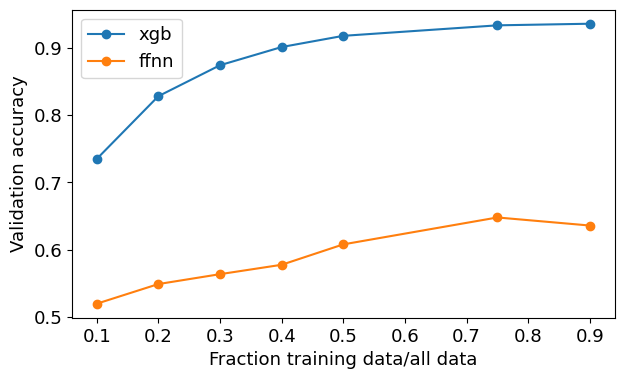

In [85]:
def plot_comparison(df):
    N = len(df['fraction'])
    x = np.unique(df['fraction'])

    acc_xgb = [df['val_acc'][i] for i in range(N) if df['model'][i] == 'XGB']
    acc_ffnn = [df['val_acc'][i] for i in range(N) if df['model'][i] == 'FFNN']

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(x, acc_xgb, 'o-', label='xgb')
    ax.plot(x, acc_ffnn, 'o-', label='ffnn')
    ax.legend()

    ax.set_xlabel("Fraction training data/all data")
    ax.set_ylabel("Validation accuracy")

plot_comparison(df)
    

The XGBoosting model significantly beats the FFNN's one in all the N'/N ratios. A better FFNN model (more neurons and layers) could slightly increase the validation accuracy, which seems to grow linearly with respect to the N'/N ratio.
In the XGboosting case the v.a. is reasonably high even with small datasets (74% at N'/N = 0.1) and quickly grows until reaching an accuracy of 95% for N'/N= 0.8 making it the best model for this specific task and data type.